This notebook demonstrates the implementation of the louvain algorithm along with experimentation and analysis of its parameters

Importing essential packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import urllib.request

Creating human PPI graph

In [2]:
df = pd.read_csv('bio-pathways-network.csv')

edges = list(zip(df['Gene ID 1'], df['Gene ID 2']))

G_human = nx.Graph()
G_human.add_edges_from(edges)

print("Human nodes:", len(G_human.nodes()), "edges:", len(G_human.edges()))

Human nodes: 21557 edges: 342353


Creating yeast PPI graph

In [3]:
urllib.request.urlretrieve(
    'http://snap.stanford.edu/deepnetbio-ismb/ipynb/yeast.edgelist',
    'yeast.edgelist'
)
yeast_file = "yeast.edgelist"
G_yeast = nx.read_edgelist(yeast_file)

print("Yeast nodes:", len(G_yeast.nodes()), "edges:", len(G_yeast.edges()))

Yeast nodes: 6526 edges: 532180


For networkx library's louvain algorithm, the threshold parameter determines the modularity gain threshold per level. If the gain of modularity between two levels is lower than the threshold, the algorithm stops and returns resulting communities.

Hence, I shall use a range of threshold values for each dataset. The threshold value that produces the best results shall be used as the final community detection result for each dataset.

This shall be judged based on silhouette, Calinski Harabasz index, Davies Bouldin Index and Noise Ratio

In [4]:
from networkx.algorithms.community import modularity
from networkx.utils import py_random_state
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

Yeast Community Detection

Total number of classes/clusters not given for the yeast ppi. Hence, resolution and max_level parameters remain at their default values of 1 and None respectively.

The threshold value shall start from 0 and increase at increments of 0.05 until it reaches 0.1

In [ ]:
thresholds = np.arange(0, 0.55, 0.05)
results = pd.DataFrame(columns=['threshold', 'modularity', 'silhouette', 'calinski_harabasz', 'davies_bouldin'])
for threshold in thresholds:
    #Conduct louvain community detection
    yeast_grps = nx.community.louvain_communities(G_yeast, threshold=threshold, seed=42)

    #Obtain modularity score
    mod = modularity(G_yeast, yeast_grps)
    results.loc[len(results)] = [threshold, mod, None, None, None]
    results.loc[results['threshold'] == threshold, 'modularity'] = mod

    #Prepare data for clustering metrics
    adj_matrix = nx.to_numpy_array(G_yeast)
    node_labels = []
    for node in G_yeast.nodes():
        label = -1  # Default label for nodes not in any community
        for idx, grp in enumerate(yeast_grps):
            if node in grp:
                label = idx
                break
        node_labels.append(label)

    #Calculate clustering metrics
    ch = calinski_harabasz_score(adj_matrix, node_labels)
    db = davies_bouldin_score(adj_matrix, node_labels)
    sil = silhouette_score(adj_matrix, node_labels)

    #Store results
    results.loc[results['threshold'] == threshold, 'silhouette'] = sil
    results.loc[results['threshold'] == threshold, 'calinski_harabasz'] = ch
    results.loc[results['threshold'] == threshold, 'davies_bouldin'] = db

results.head(20)

,threshold,modularity,silhouette,calinski_harabasz,davies_bouldin
0,0.00,0.165841,-0.352927,29.146463,7.784421
1,0.05,0.165841,-0.352927,29.146463,7.784421
2,0.10,0.165841,-0.352927,29.146463,7.784421
3,0.15,0.165841,-0.352927,29.146463,7.784421
4,0.20,0.159008,-0.340919,14.153778,6.715730
5,0.25,0.159008,-0.340919,14.153778,6.715730
6,0.30,0.159008,-0.340919,14.153778,6.715730
7,0.35,0.159008,-0.340919,14.153778,6.715730
8,0.40,0.159008,-0.340919,14.153778,6.715730
9,0.45,0.159008,-0.340919,14.153778,6.715730


In the table above, threshold values of range 0 to 0.15 produces the best calinski harabasz score. 

Although the silhouette and davies bouldin score improve at threshold 0.2, the drop in calinski harabasz score is far more significant.

The three metrics appear to be consistent, only changing when the modularity gain threshold exceeded a certain number. This is visualized in the line graphs below

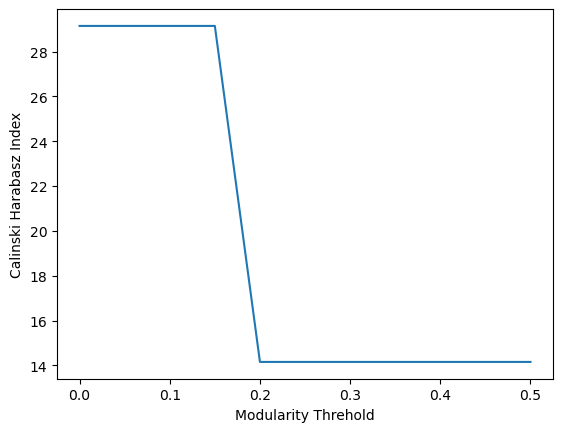

In [6]:
plt.xlabel('Modularity Threhold')
plt.ylabel('Calinski Harabasz Index')
plt.plot(results['threshold'], results['calinski_harabasz'])

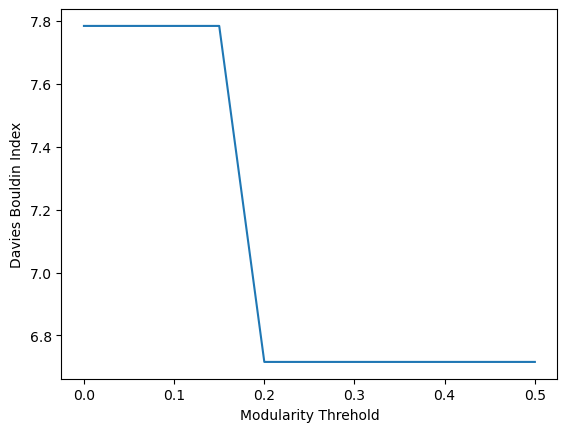

In [7]:
plt.xlabel('Modularity Threhold')
plt.ylabel('Davies Bouldin Index')
plt.plot(results['threshold'], results['davies_bouldin'])

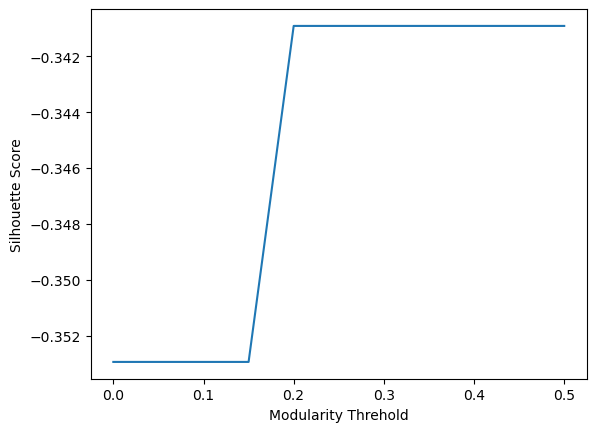

In [8]:
plt.xlabel('Modularity Threhold')
plt.ylabel('Silhouette Score')
plt.plot(results['threshold'], results['silhouette'])

The finalized yeast communities shall use a threshold of 0

In [9]:
yeast_grps = nx.community.louvain_communities(G_yeast, seed=42)

Yeast Cluster Distribution

The graph below shows a greatly uneven distribution of yeast nodes between clusters

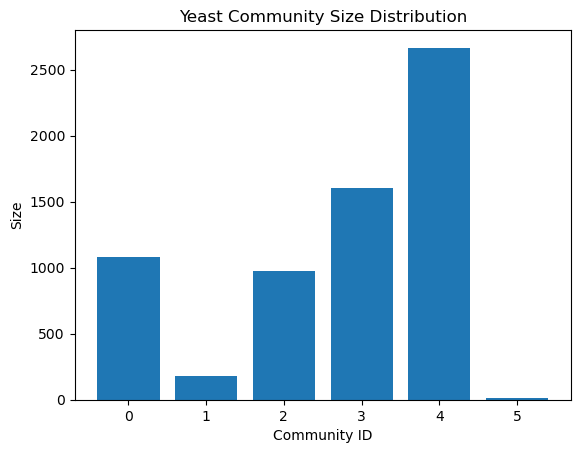

In [10]:
yeast_df = pd.DataFrame()
yeast_df['Community ID'] = range(len(yeast_grps))
yeast_df['Members'] = None

for idx, community in enumerate(yeast_grps):
    yeast_df.at[idx, 'Members'] = list(community)
    yeast_df.at[idx, 'Size'] = len(community)

plt.bar(yeast_df['Community ID'], yeast_df['Size'])
plt.xlabel('Community ID')
plt.ylabel('Size')
plt.title('Yeast Community Size Distribution')
plt.show()


Human Community Detection

Number of diseases/clusters for this dataset is 519. Hence the resolution parameter is used. 

As shown in the yeast dataset experiment above, the threshold parameter doesn't produce signifiant change to the quality of clustering, hence it will be kept at the default value

The below is the result when the threshold is at the default value, along with metrics.

In [11]:
human_grps = nx.community.louvain_communities(G_human, resolution=13.25295, seed=42)

print("Number of communities: ", len(human_grps))
print("Modularity: ", modularity(G_human, human_grps))
print("Calinski Harabasz Index: ", calinski_harabasz_score(adj_matrix, node_labels))
print("Davies Bouldin Score: ", davies_bouldin_score(adj_matrix, node_labels))
print("Silhouette Score: ", silhouette_score(adj_matrix, node_labels))

Number of communities:  519
Modularity:  0.2306744075087289
Calinski Harabasz Index:  14.15377845285543
Davies Bouldin Score:  6.71572965553244
Silhouette Score:  -0.3409185116407015


Checking accuracy of communities matched 

In [12]:
human_df = pd.read_csv('bio-pathways-associations.csv')

human_df['Matched Community'] = None
human_df['Percentage Match'] = 0.0

for community in human_grps:
    community_set = set(community)
    for idx, row in human_df.iterrows():
        gene_set = set(map(int ,row['Associated Gene IDs'].split(', ')))
        intersection = community_set.intersection(gene_set)
        if len(intersection) > 0:
            percentage_match = len(intersection) / len(gene_set) * 100
            if percentage_match > row['Percentage Match']:
                human_df.at[idx, 'Matched Community'] = community
                human_df.at[idx, 'Percentage Match'] = percentage_match

human_df.to_csv('bio-pathways-associations-with-communities.csv', index=False)
human_df.head(10)

,Disease ID,Disease Name,Associated Gene IDs,Matched Community,Percentage Match
0,C0036095,Salivary Gland Neoplasms,"1462, 1612, 182, 2011, 2019, 2175, 2195, 23209...","{55808, 8704, 728577, 79369, 83468, 8720, 8722...",8.888889
1,C0033941,"Psychoses, Substance-Induced","135, 1636, 207, 2099, 2912, 2950, 3350, 3362, ...","{152579, 2054, 2055, 51208, 11270, 7180, 23566...",11.764706
2,C0043459,Zellweger Syndrome,"3295, 5189, 5190, 5192, 5193, 5194, 5195, 5567...","{5824, 11264, 5825, 373509, 5192, 5193, 201164...",33.333333
3,C0033860,Psoriasis,"100271719, 10318, 10498, 10547, 10758, 10866, ...","{307200, 3589, 3590, 2057, 3596, 3597, 3598, 5...",6.250000
4,C0027726,Nephrotic Syndrome,"1277, 1282, 1284, 2, 213, 2152, 2247, 2262, 29...","{4099, 714, 3082, 3083, 12, 5648, 5653, 6678, ...",23.809524
5,C0338480,Common Migraine,"221692, 23063, 23245, 338342, 4035, 4209, 6863...","{57600, 60673, 9474, 115201, 67841, 2565, 2570...",8.333333
6,C0026636,Mouth Diseases,"10036, 2189, 2937, 3301, 51182, 54541, 56603, ...","{5890, 51460, 8968, 474382, 41743, 8208, 51230...",16.666667
7,C1838979,MITOCHONDRIAL COMPLEX I DEFICIENCY,"126328, 137682, 25915, 29078, 374291, 4535, 45...","{1537, 133121, 4358, 54539, 125965, 374291, 79...",82.142857
8,C0236969,Substance-Related Disorders,"1012, 10160, 10207, 10257, 105, 1080, 11278, 1...","{2560, 2561, 2562, 2566, 147463, 57863, 2567, ...",4.385965
9,C0002878,"Anemia, Hemolytic","2056, 2539, 2729, 2821, 2936, 3043, 3162, 3440...","{10753, 5634, 5635, 5636, 2821, 6675, 2582, 10...",16.666667


The below statistics show the extent each community was matched correctly by Louvain Algorithm

The maximum percentage match is only 85% and the median and average percentage match are very low, hence Louvain algorithm is not accurate at precise identification of a large number of communities

In [13]:
#max percentage match
max_match = human_df['Percentage Match'].max()
print(f'Maximum Percentage Match: {max_match}%')

#min percentage match
min_match = human_df['Percentage Match'].min()
print(f'Minimum Percentage Match: {min_match}%')

#median percentage match
median_match = human_df['Percentage Match'].median()
print(f'Median Percentage Match: {median_match}%')

#average percentage match
avg_match = human_df['Percentage Match'].mean()
print(f'Average Percentage Match: {avg_match}%')

Maximum Percentage Match: 85.0%
Minimum Percentage Match: 2.2222222222222223%
Median Percentage Match: 10.0%
Average Percentage Match: 13.529805926725906%


PCA Visualization

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

In [15]:
def pca_transform(graph:nx.Graph, communities:list, title:str):
    #1. Perform PCA on the adjacency matrix
    adj_matrix = nx.to_numpy_array(graph)
    pca_result = pca.fit_transform(adj_matrix)

    #2. Generate Labels for each node based on community membership
    node_labels = []
    for node in graph.nodes():
        label = -1  # Default label for nodes not in any community
        for idx, community in enumerate(communities):
            if node in community:
                label = idx
                break
        node_labels.append(label)

    #3. Plot the PCA results with community-based coloring
    cm = ''
    if len(communities) <= 20:
        cm = 'viridis'
    else:
        cm = 'hsv'
    plt.figure()
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], s=8, alpha=0.85, c=node_labels, cmap=cm)
    # Add colorbar to show community labels
    cbar = plt.colorbar(scatter)
    cbar.set_label('Community', rotation=270, labelpad=15)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

Yeast PCA

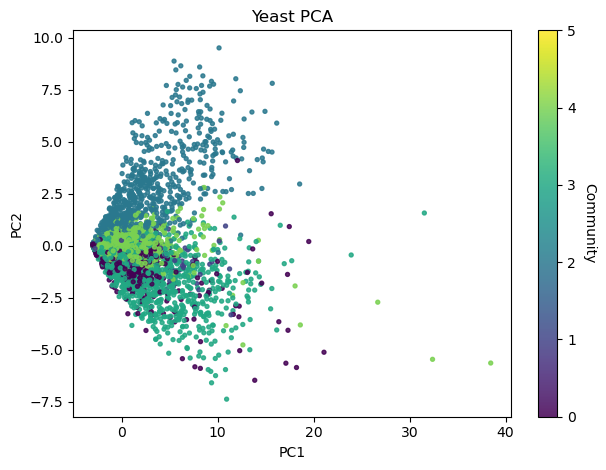

In [16]:
pca_transform(G_yeast, yeast_grps, "Yeast PCA")

Human PCA

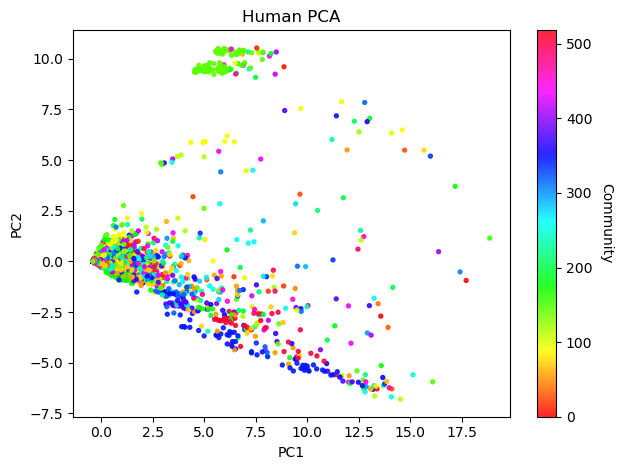

In [17]:
pca_transform(G_human, human_grps, "Human PCA")